# Estimating beta for every S&P 500 stock

This notebook scrapes the current list of S&P 500 companies, downloads five years of prices, turns them into monthly returns, and then fits a market-model regression for each stock against the SPY benchmark. From each regression we keep alpha, beta, R-squared and the residual standard error, then look at how beta varies across industries.

Run the cells in order. It reaches out to Wikipedia and Yahoo Finance, so the data-gathering cell needs a working internet connection and will take a little time.

## 1. Importing the libraries

We bring in `requests` and `BeautifulSoup` for reading the Wikipedia page, pandas for the data tables, `yfinance` for the price download, numpy for the maths, matplotlib and seaborn for the chart, statsmodels for the regressions, and `time` for measuring how long the analysis runs.

In [1]:
# Think of this section as gathering your tools before starting a project. Each
# "import" statement brings in a pre-built set of tools (a "library") that helps
# us perform a specific task without having to write the code from scratch.

# The 'requests' library allows our Python script to act like a web browser,
# enabling it to download the content of web pages.
import requests

# 'BeautifulSoup' is a specialized tool for parsing HTML and XML documents.
# It takes the messy raw HTML code from a webpage and turns it into a structured
# object that's easy to navigate and search.
from bs4 import BeautifulSoup

# 'pandas' is the most essential library for data science in Python. It provides
# the "DataFrame," a powerful object that lets us work with data in tables (like
# an Excel spreadsheet, but with much more power). We give it the nickname 'pd'.
import pandas as pd

# The 'datetime' library provides tools for working with dates and times. We
# specifically import the 'date' object to define our start and end dates.
from datetime import date

# The 'yfinance' library is a popular and easy-to-use tool for downloading
# historical market data from Yahoo! Finance.
import yfinance as yf

# 'numpy' is the fundamental library for numerical computing in Python. It's
# especially good at performing mathematical operations on large arrays of numbers
# very quickly. We use it here for the square root function.
import numpy as np

# 'matplotlib' is the foundational plotting library in Python. It gives us fine-grained
# control over every aspect of a visualization. We give it the nickname 'plt'.
import matplotlib.pyplot as plt

# 'seaborn' is built on top of Matplotlib and provides a high-level interface for
# creating beautiful and informative statistical graphics. It makes complex plots easier.
import seaborn as sns

# 'statsmodels' is a powerful library for estimating and interpreting statistical models.
# We import its 'formula.api', which allows us to define our regression model using a
# simple, readable formula syntax (like 'Y ~ X'), similar to the R programming language.
import statsmodels.formula.api as smf

# The 'time' library gives us access to time-related functions. We will use it to
# measure how long our regression analysis takes to run.
import time

## 2. Gathering the data

Two ingredients are collected here. First the current S&P 500 constituents and their GICS sector, scraped from Wikipedia and tidied to a ticker-and-industry table. Then five years of daily adjusted closing prices for every one of those tickers plus SPY, downloaded from Yahoo Finance. Adjusted close is used because it already accounts for dividends and splits.

In [2]:
# The goal of this section is to collect our two raw ingredients:
# 1. An up-to-date list of all companies in the S&P 500 index and their industries.
# 2. The historical daily stock prices for each of those companies, plus the SPY ETF.

# --- Step 2.1: Get the list of S&P 500 companies from Wikipedia ---

# We store the URL of the Wikipedia page in a variable for easy access.
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
# It's considered polite practice ("polite scraping") to identify our script when
# we request data from a website. We do this by setting a 'User-Agent' in the request headers.
headers = {'User-Agent': 'Stock Analyzer/1.0 (kc@example.com)'}
# We use the 'requests.get()' function to send an HTTP GET request to the URL,
# which is like asking the server for the content of the page. The server's
# response is stored in the 'response' object.
response = requests.get(url, headers=headers)
# We then use 'BeautifulSoup' to parse the raw HTML content of the page ('response.content').
# 'html.parser' is the built-in Python parser we'll use to process the HTML.
soup = BeautifulSoup(response.content, 'html.parser')
# 'pandas.read_html()' is a powerful function that scans the provided HTML and
# automatically extracts any tables it finds. It returns a list of DataFrames.
# Since the first table on the page ([0]) is the one we want, we select it.
constituents_table = pd.read_html(str(soup.find('table')))[0]

# --- Step 2.2: Clean the constituents data ---
# We use a "method chain" here, where each operation is on a new line. This makes
# the sequence of data cleaning steps clear and readable, like a recipe.
constituents_df = (
    constituents_table
    # The '.rename()' method allows us to change the names of the columns. We
    # choose simpler, script-friendly names (lowercase, no spaces).
    .rename(columns={'Symbol': 'ticker', 'GICS Sector': 'industry'})
    # After renaming, we select ONLY the columns we need for our analysis using
    # double square brackets. This keeps our DataFrame tidy and efficient.
    [['ticker', 'industry']]
)
print("--- S&P 500 Constituents (Sample) ---")
# '.head()' is a useful method to display the first 5 rows of a DataFrame,
# allowing us to quickly check that our data was loaded and cleaned correctly.
print(constituents_df.head())

# --- Step 2.3: Download historical stock prices from Yahoo Finance ---
# We need a list of all ticker symbols to download. We get this by taking the
# 'ticker' column from our DataFrame and converting it to a Python list with '.tolist()'.
# We then add 'SPY' to this list, as it's an ETF that tracks the S&P 500 and will
# serve as our market benchmark for the regressions.
tickers_to_download = constituents_df['ticker'].tolist() + ['SPY']
# We dynamically set the date range. 'date.today()' gets the current date.
end_date = date.today()
# The start date is set to January 1st, five years prior to the current year.
start_date = date(end_date.year - 5, 1, 1)

print(f"\nDownloading historical stock data from {start_date} to {end_date}...")
# This is the main function call to yfinance. It downloads all the data we need in one go.
adj_close_df = yf.download(
    tickers_to_download, # The list of tickers we want.
    start=start_date,    # The start of our historical date range.
    end=date.today(),      # The end of our date range.
    auto_adjust=False,   # We set this to False because we want to specifically select the 'Adj Close' column.
    progress=False       # Hides the download progress bar for a cleaner output.
)['Adj Close'] # From the downloaded data, we select only the 'Adj Close' (Adjusted Close) price.
               # This price is adjusted for dividends and stock splits, making it the most accurate
               # price to use for calculating historical returns.
print("Download complete.")

/var/folders/nr/tyby6qh141x5bfmpw02f0yv40000gn/T/ipykernel_12628/3464810777.py:22: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  constituents_table = pd.read_html(str(soup.find('table')))[0]


--- S&P 500 Constituents (Sample) ---
  ticker                industry
0    MMM             Industrials
1    AOS             Industrials
2    ABT             Health Care
3   ABBV             Health Care
4    ACN  Information Technology



$BF.B: possibly delisted; no price data found  (1d 2021-01-01 -> 2026-09-06)
$BRK.B: possibly delisted; no timezone found

2 Failed downloads:
['BF.B']: possibly delisted; no price data found  (1d 2021-01-01 -> 2026-09-06)
['BRK.B']: possibly delisted; no timezone found


Download complete.


## 3. Turning prices into monthly returns

Daily prices are too noisy for this, so we resample to month-end prices, take the percentage change to get monthly returns, drop the first empty row, and rename the SPY column so the regression formula reads cleanly. Missing values are left in place on purpose, since not every stock existed for the full five years.

In [7]:
# The goal here is to convert the raw daily prices into the monthly returns
# that we will use in our regression analysis. Daily prices are too noisy for
# this type of analysis, so we smooth them out by using monthly data points.

# We use another method chain to perform the calculation in a series of clear steps.
monthly_returns_wide = (
    adj_close_df
    # Step A: '.resample("ME")' groups the daily data into monthly bins.
    # '.last()' then selects the LAST valid price for each month. This gives us
    # a DataFrame of month-end prices for every stock.
    .resample('ME').last()

    # Step B: '.pct_change()' calculates the percentage change from the previous row
    # to the current row. Since our rows are now months, this automatically computes
    # the monthly return for each stock.
    .pct_change()

    # Step C: The very first row of the result will be empty (NaN) because there's no
    # prior month to calculate a return from. '.iloc[1:]' selects all rows from
    # the second row to the end, effectively dropping that first empty row.
    .iloc[1:]
    
    # Step D: We rename the 'SPY' column to 'SPY_Return'. This makes our
    # regression formula later more readable and explicit.
    .rename(columns={'SPY': 'SPY_Return'})
)
print("\n--- Monthly Returns (Wide Format, with NaNs preserved) ---")
# We print the head of the resulting DataFrame to see what our monthly returns look like.
# Note that there will be 'NaN' (Not a Number) values for stocks that didn't exist
# or weren't in the index for the full 5-year period. This is expected.
print(monthly_returns_wide.head())


--- Monthly Returns (Wide Format, with NaNs preserved) ---
Ticker             A      AAPL      ABBV      ABNB       ABT      ACGL  \
Date                                                                     
2021-02-28  0.015811 -0.079712  0.051327  0.123727 -0.030827  0.140401   
2021-03-31  0.041533  0.007340  0.004455 -0.089217  0.000501  0.071189   
2021-04-30  0.052724  0.076218  0.042836 -0.081036  0.005682  0.034923   
2021-05-31  0.033598 -0.050497  0.015247 -0.187077 -0.028564  0.004533   
2021-06-30  0.070079  0.099109 -0.004947  0.090741 -0.006172 -0.023816   

Ticker           ACN      ADBE       ADI       ADM  ...        WY      WYNN  \
Date                                                ...                       
2021-02-28  0.037120  0.001962  0.062156  0.139282  ...  0.085925  0.323521   
2021-03-31  0.101036  0.034155 -0.004749  0.007423  ...  0.056434 -0.048281   
2021-04-30  0.052914  0.069357 -0.012381  0.107544  ...  0.089045  0.024168   
2021-05-31 -0.026934 -0.00

/var/folders/nr/tyby6qh141x5bfmpw02f0yv40000gn/T/ipykernel_12628/1567972731.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


## 4. One regression per stock

This is the heart of the notebook. `calculate_regression_stats` fits each stock's monthly returns against SPY's, first dropping any months where either series is missing and skipping stocks with fewer than 35 valid months. From each fit it returns alpha, beta, R-squared and the residual standard error. We then apply that function across every stock column, transpose the result, join the industry labels back on, and drop any stock where the regression could not run.

In [8]:
# This is the analytical core of the script. The goal is to measure the relationship
# between each individual stock's returns and the overall market's returns (SPY).
# We do this by fitting a linear regression model for each stock.

# We define a function to perform the regression. A function is a reusable block of
# code that performs a specific task. This is efficient because we can write the
# logic once and then apply it to hundreds of stocks.
def calculate_regression_stats(stock_data, market_return_col):
    # This function takes two inputs: 'stock_data' (the monthly returns for one
    # stock) and 'market_return_col' (the monthly returns for SPY).

    # We combine the stock's returns and the market's returns into a single, temporary
    # DataFrame. 'axis=1' means we are combining them as columns.
    # '.dropna()' is CRITICAL here. It removes any rows where EITHER the stock OR SPY
    # has a missing value. This ensures we only run the regression on valid, paired data points.
    regression_df = pd.concat([stock_data, market_return_col], axis=1).dropna()

    # This is a data quality check. A reliable regression requires a minimum number
    # of data points. We set a threshold of 35 months (almost 3 years). If there are
    # fewer than 35 valid months, we skip the calculation and return empty results.
    if len(regression_df) < 35:
        return pd.Series({'Alpha': np.nan, 'Beta': np.nan, 'R_Squared': np.nan, 'Residual_SE': np.nan})

    # This line constructs the regression formula as a string.
    # The `~` means "is explained by". So, "Stock Return is explained by SPY_Return".
    # We must wrap the stock's name in `Q()` because the ticker symbol (e.g., "AAPL")
    # is stored in a variable, and `Q()` tells the model to look for a column with that name.
    model_formula = f'Q("{stock_data.name}") ~ SPY_Return'

    # Here, we use statsmodels to define and fit the Ordinary Least Squares (OLS) regression model.
    # '.fit()' runs the actual calculation to find the best-fit line.
    model = smf.ols(formula=model_formula, data=regression_df).fit()

    # After the model is fit, we extract the key results.
    # Alpha is the model's intercept. It represents the stock's theoretical excess return if the market had a 0% return.
    alpha = model.params.get('Intercept', np.nan)
    # Beta is the coefficient of our market variable. It measures the stock's volatility relative to the market.
    beta = model.params.get('SPY_Return', np.nan)
    # R-squared measures what percentage of the stock's price movements can be explained by the market's movements.
    r_squared = model.rsquared
    # Residual Standard Error measures the typical size of the model's prediction errors. A smaller value is better.
    residual_se = np.sqrt(model.mse_resid)

    # The function returns all the calculated statistics packaged neatly as a pandas Series (which will become a row in our final results).
    return pd.Series({'Alpha': alpha, 'Beta': beta, 'R_Squared': r_squared, 'Residual_SE': residual_se})

print("\n--- Fitting Regression Models for Each Stock ---")
# We start a high-precision timer right before the main calculation begins.
start_time = time.perf_counter()

# This method chain orchestrates the entire analysis for all stocks.
regression_results = (
    # Step A: We start with our monthly returns, but drop the 'SPY_Return' column
    # because we don't want to run a regression of SPY against itself.
    monthly_returns_wide.drop(columns='SPY_Return')
    # Step B: '.apply()' is the workhorse. It iterates through EVERY column (i.e., every stock)
    # of the DataFrame and runs our 'calculate_regression_stats' function on it.
    .apply(calculate_regression_stats, market_return_col=monthly_returns_wide[['SPY_Return']])
    # Step C: The result of '.apply()' has tickers as columns. '.T' transposes the
    # DataFrame, flipping it so that tickers become the rows, a more standard format.
    .T
    # Step D: We merge our regression results with our original industry information.
    # This is like a VLOOKUP in Excel, matching on the ticker symbol to add the correct industry to each row.
    .merge(constituents_df.set_index('ticker'), left_index=True, right_index=True)
    # Step E: A final cleanup step to remove any stocks where the regression failed
    # (e.g., because they had too little data and our function returned NaNs).
    .dropna(subset=['Beta'])
)
# We stop the timer immediately after the calculation is finished.
end_time = time.perf_counter()
# We calculate the duration and print a summary of the work done.
duration = end_time - start_time
num_regressions = len(regression_results)
print(f"Successfully fit {num_regressions} regressions in {duration:.2f} seconds.")
print("\n--- Final Regression Results (Sample) ---")
# We print the first few rows of our final, combined results table.
print(regression_results.head())


--- Fitting Regression Models for Each Stock ---
Successfully fit 494 regressions in 0.73 seconds.

--- Final Regression Results (Sample) ---
         Alpha      Beta  R_Squared  Residual_SE                industry
A    -0.009008  1.257657   0.446650     0.061535             Health Care
AAPL  0.002090  1.077454   0.443839     0.053019  Information Technology
ABBV  0.014740  0.298562   0.042780     0.062081             Health Care
ABNB -0.008623  1.097621   0.200446     0.096365  Consumer Discretionary
ABT  -0.005947  0.582289   0.161781     0.058263             Health Care


## 5. Beta by industry

A boxplot showing the spread of betas within each industry, with the industries ordered from most to least volatile on average. The dashed red line at beta of 1 marks the volatility of the market itself, so anything to the right of it moves more than the market and anything to the left moves less.


--- Generating Black & White Sorted Beta Boxplot ---


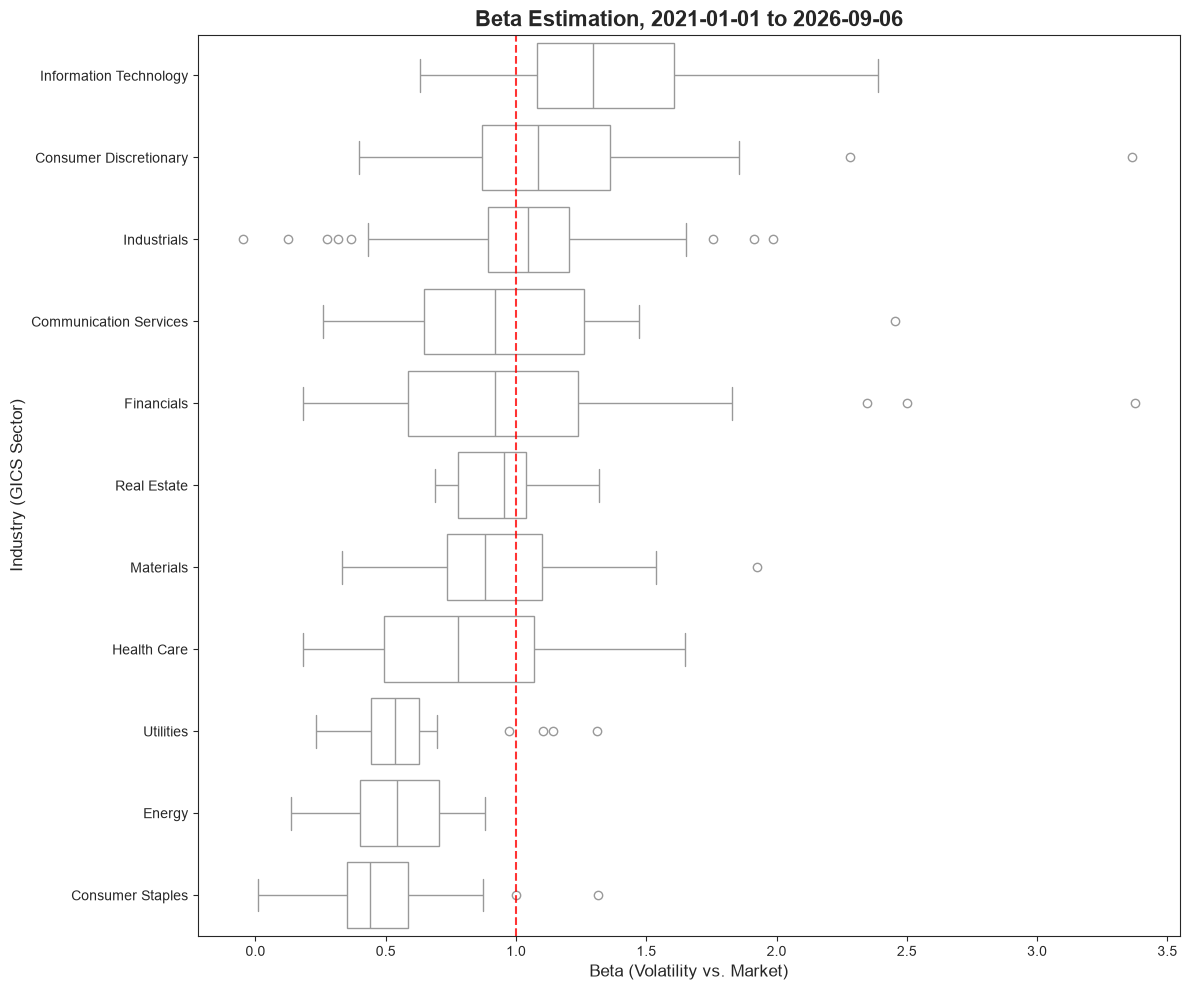

In [9]:
# The goal of this visualization is to compare the distribution of Betas across
# all the different industries in a clear and concise way.

print("\n--- Generating Black & White Sorted Beta Boxplot ---")

# --- Step 5.1: Prepare the sorting order for the plot ---
# To make the plot more insightful, we want to sort the industries from highest
# average beta to lowest. This makes it easy to see which sectors are most volatile.
industry_order = (
    regression_results
    .groupby('industry')       # This groups all the stocks by their industry, like a pivot table.
    ['Beta']                   # We select the 'Beta' column to perform a calculation on.
    .mean()                    # We calculate the average (mean) Beta for each industry group.
    .sort_values(ascending=False) # We sort these average Betas from highest to lowest.
    .index                     # Finally, we get the list of industry names in this new sorted order.
)

# --- Step 5.2: Create the plot ---
# Set a clean visual style for the plot with visible axis ticks.
sns.set_style("ticks")
# Create the "canvas" for our plot and set its size in inches (width, height).
plt.figure(figsize=(12, 10))
# This is the main command to create the boxplot using the Seaborn library.
# A boxplot is a standardized way of displaying the distribution of data based
# on a five-number summary (minimum, first quartile, median, third quartile, and maximum).
sns.boxplot(
    data=regression_results, # The DataFrame containing our data.
    x='Beta',                # The variable whose distribution we want to see (will be on the horizontal axis).
    y='industry',            # The variable we use to group the data (will be on the vertical axis).
    order=industry_order,    # This tells Seaborn to draw the industries in our custom sorted order.
    color="white"            # We set the fill color to white for a clean, black-and-white look.
)
# This adds a vertical dashed line to the plot at x=1. This is a crucial reference
# point, as a Beta of 1 represents the volatility of the market itself.
plt.axvline(x=1, color='red', linestyle='--', alpha=0.8)
# We create a dynamic title that includes the actual start and end dates of our analysis.
title_text = f"Beta Estimation, {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}"
# We set the title of the plot, making it larger and bold for emphasis.
plt.title(title_text, fontsize=16, fontweight='bold')
# We add descriptive labels to the x and y axes.
plt.xlabel('Beta (Volatility vs. Market)', fontsize=12)
plt.ylabel('Industry (GICS Sector)', fontsize=12)
# This command automatically adjusts plot parameters to give a tight layout,
# preventing labels from overlapping.
plt.tight_layout()
# This final command displays the plot we have built.
plt.show()

## 6. Summary statistics

Finally we summarise beta by industry (count, mean, spread and range) and list the ten most and ten least volatile individual stocks.

In [10]:
print("\n--- Beta Summary Statistics by Industry ---")
# Group the results by industry and calculate summary stats for Beta
beta_summary = regression_results.groupby('industry')['Beta'].agg(
    ['count', 'mean', 'std', 'min', 'max']
).round(3)
print(beta_summary)

print("\n--- Stocks with Highest Betas (Most Volatile) ---")
print(regression_results.nlargest(10, 'Beta')[['Beta', 'industry']])

print("\n--- Stocks with Lowest Betas (Least Volatile) ---")
print(regression_results.nsmallest(10, 'Beta')[['Beta', 'industry']])


--- Beta Summary Statistics by Industry ---
                        count   mean    std    min    max
industry                                                 
Communication Services     23  0.977  0.493  0.258  2.453
Consumer Discretionary     47  1.155  0.526  0.397  3.366
Consumer Staples           33  0.481  0.250  0.009  1.316
Energy                     21  0.519  0.209  0.136  0.882
Financials                 75  0.967  0.535  0.183  3.377
Health Care                58  0.783  0.390  0.181  1.650
Industrials                80  1.028  0.356 -0.050  1.984
Information Technology     71  1.355  0.401  0.633  2.388
Materials                  25  0.936  0.377  0.332  1.923
Real Estate                30  0.949  0.185  0.690  1.318
Utilities                  31  0.586  0.245  0.231  1.311

--- Stocks with Highest Betas (Most Volatile) ---
          Beta                industry
COIN  3.376995              Financials
CVNA  3.365552  Consumer Discretionary
XYZ   2.498868              Finan